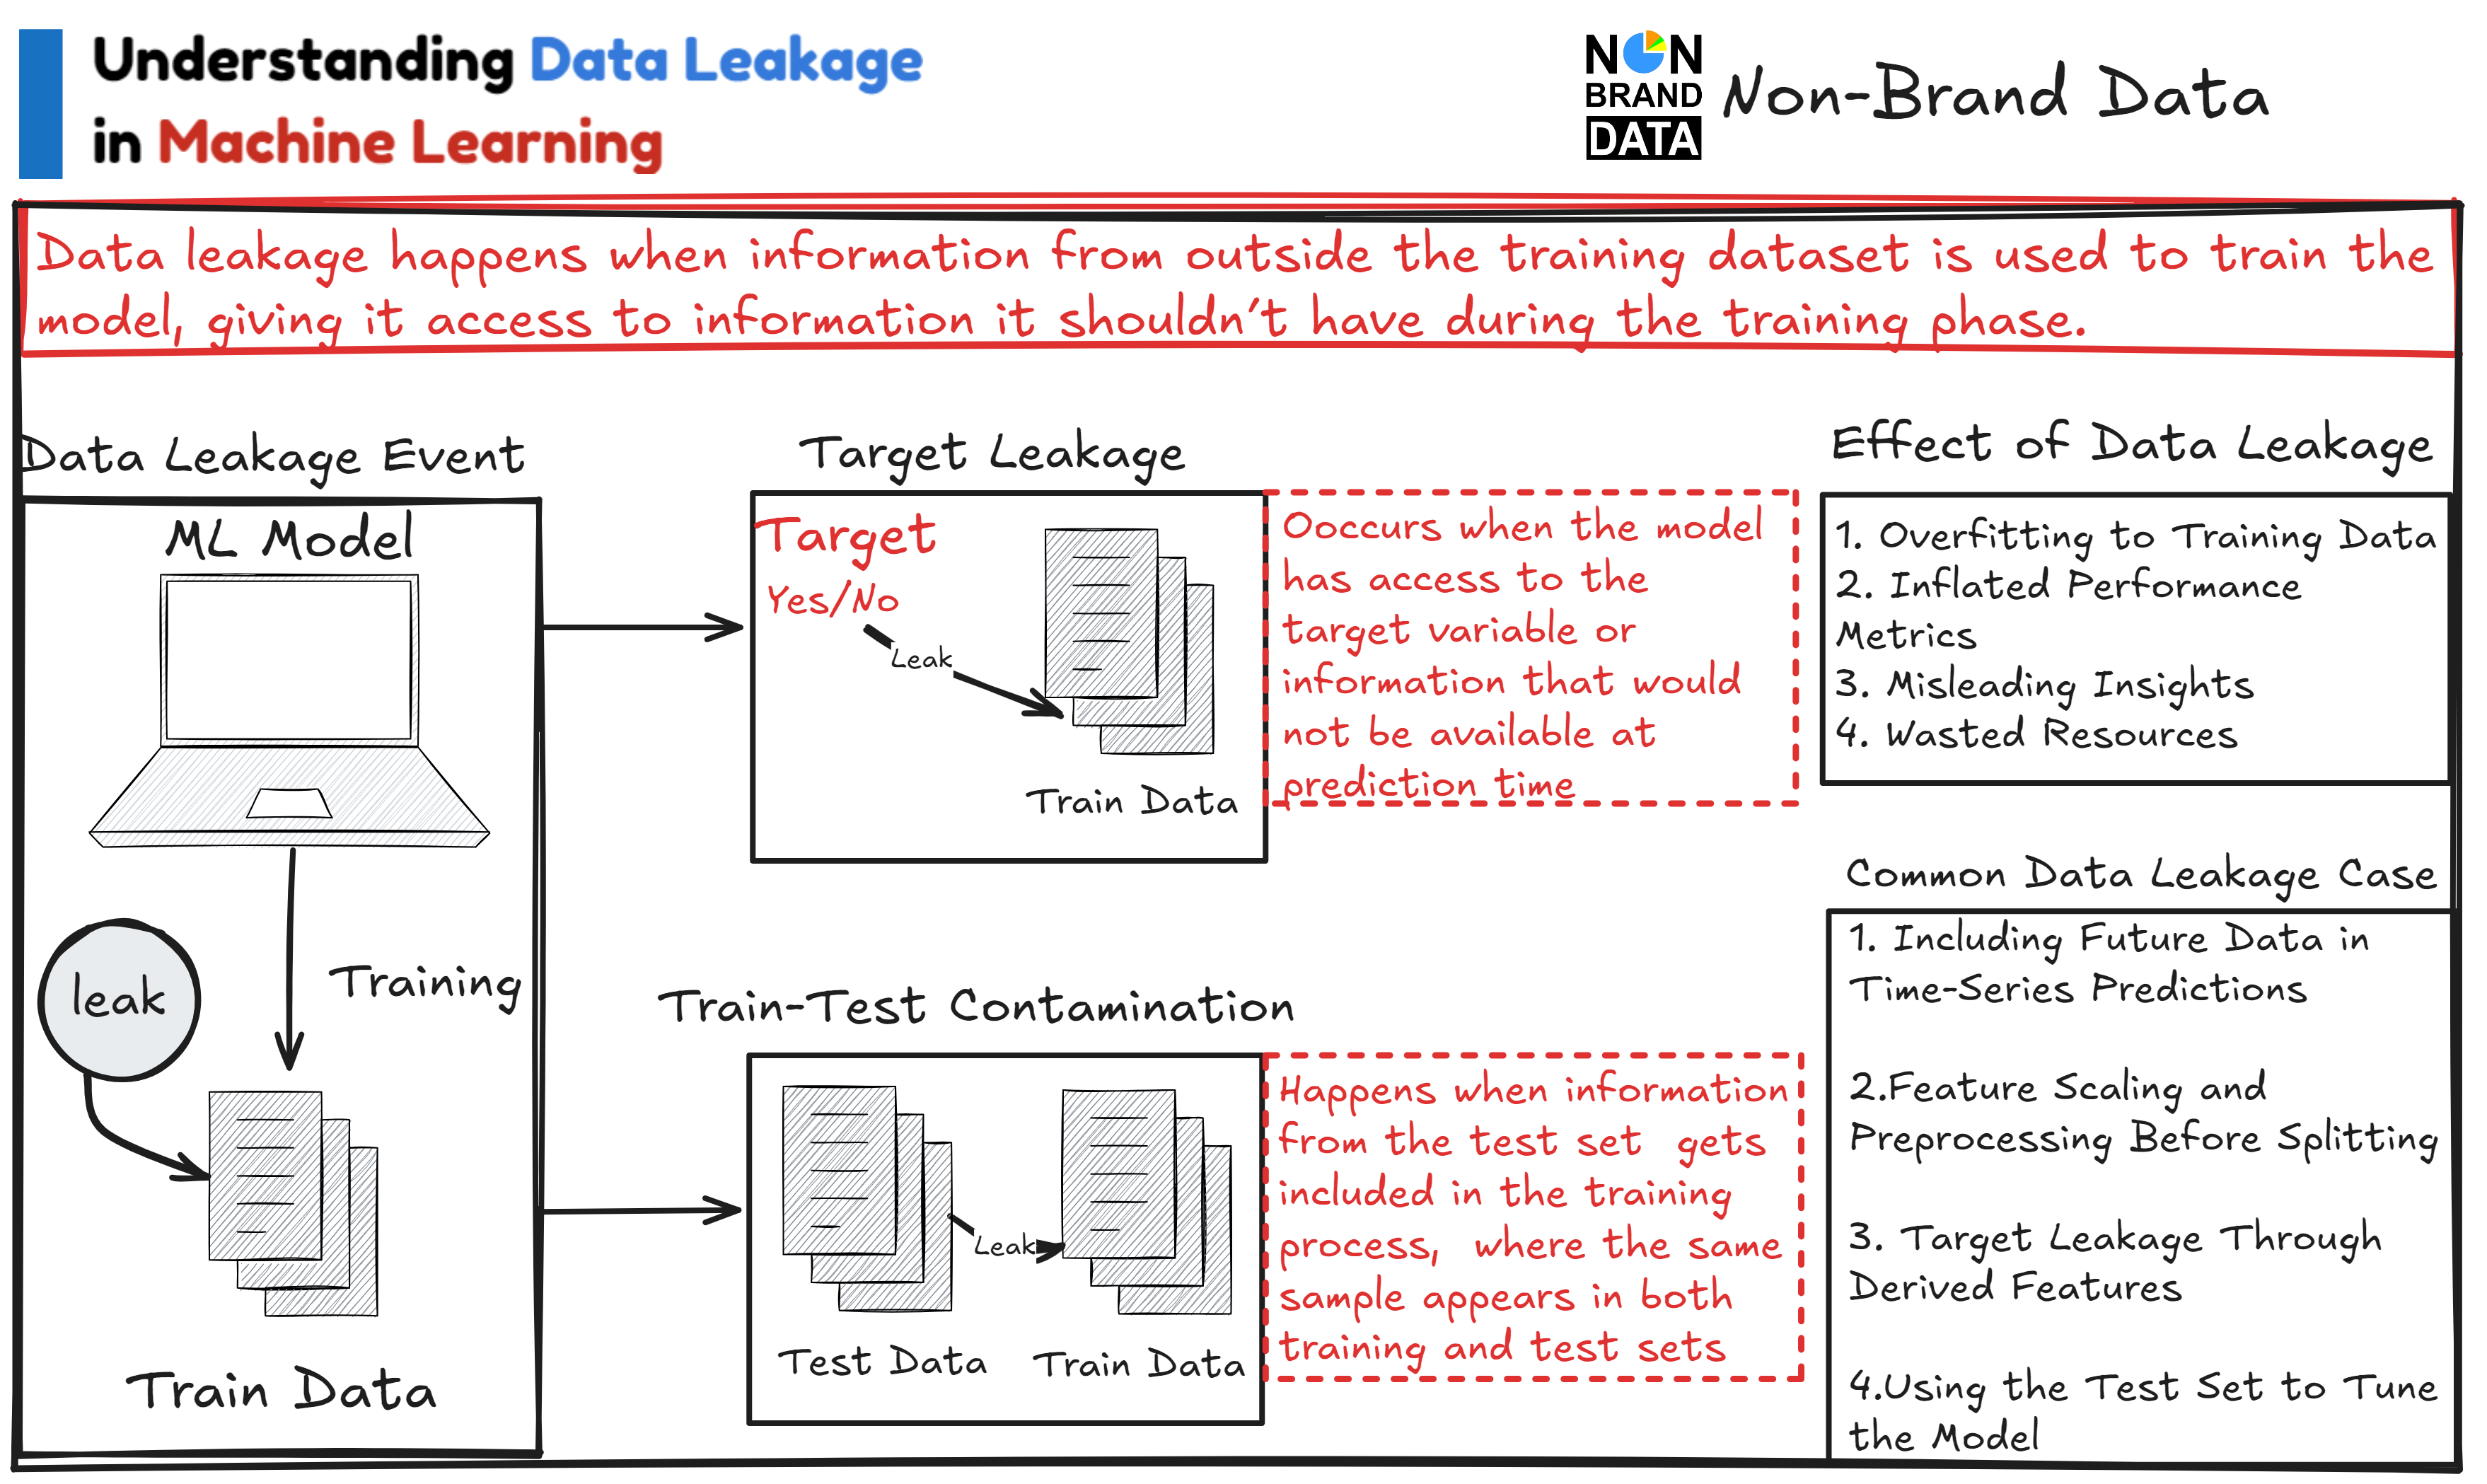![image.png]

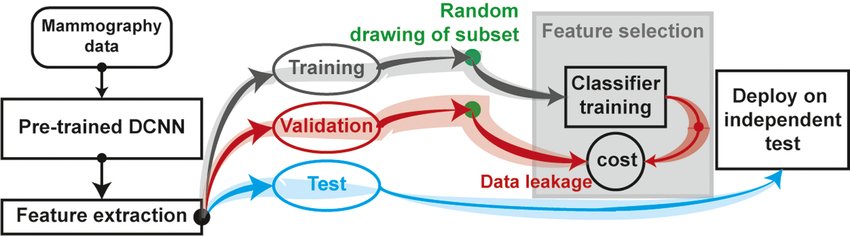![image.png]

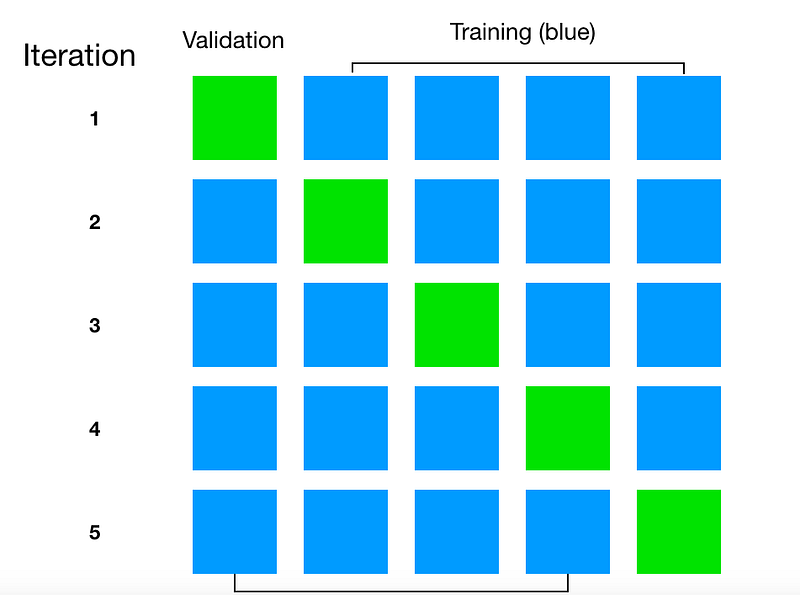![image.png]

1. #### What is Data Leakage ?
   > `Data Leakage` occurs when information that should not be available at `prediction time` is used during `model training`

* Means model is cheating. it learns from.

  > Future data
  > 
  > Target-related information
  > 
  > Test data
  > 
  > Aggregated statistics from the full dataset.

2. #### Types of data leakage ?

   1. Target Leakage (Most Dangerous)
      > When a `Feature` directly or indirectly contains the information about target.

| Feature                              | Value |
| ------------------------------------ | ----- |
| Loan Approved                        | Yes   |
| **Loan Status (Paid / Defaulted)**   | Paid  |

      >  Here , Loan status already tells the answer 




2. Train–Test Leakage

   > When test data influences training.

Common causes:

* Scaling before splitting

* Feature selection using full dataset

* PCA on entire dataset


Wrong 
> scaler.fit(X)       # uses full data

> X_train, X_test = split(X)

Correct
> scaler.fit(X_train)

> X_test = scaler.transform(X_test)


3.  Time-Based Leakage

> Using future data to predict the past.

* Stock price prediction:

> Training on data from 2023

> Testing on data from 2022

4. Cross-Validation Leakage
   > When preprocessing happens outside CV loop.

Wrong:
> X_scaled = scaler.fit_transform(X)

>cross_val_score(model, X_scaled, y)

Correct:
>Pipeline([

>  ('scaler', StandardScaler()),

>  ('model', LogisticRegression())

>])



3. How Data Leakage Happens

    1. Bad Data Splitting
       * Splitting after preprocessing.
       * Random split in time-series data.

    2. Feature Engineering Mistakes.
       * Aggregate using whole dataset.
       * Using post-event features

         > Example --> Average customer spend including future purchases

    3. Human Assumptions

        * “This feature should be okay”

        * “Accuracy is very high — model is great!”

           >High accuracy is often a warning sign
       

4. How to prevent data leakage

    1. split first , then process later

    2. Ask this question
  
       > will this feature exist at prediction time ? if not then remove

     3. Respect Time
  
         > use time-based split
         
         > never shuffle time-series data

      4. Use pipelines
  
         > pipelines automatically prevent leakage.

      5. monitor unrealistic accuracy
  
         > 99% accuracy on real data
         
         > double-check feature and splits